In [24]:
import torch
import torch.nn as nn
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import seaborn as sns

In [25]:
class AE(nn.Module):
    def __init__(self, input_size, latent_size):
        super(AE, self).__init__()
        self.input_size = input_size
        self.latent_size = latent_size

        # encoder network
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 56), nn.ReLU(),
            nn.Linear(56, 28), nn.ReLU(),
            nn.Linear(28, latent_size)
        )
        # decoder network
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 28), nn.ReLU(),
            nn.Linear(28, 56), nn.ReLU(),
            nn.Linear(56, input_size)
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)
        
#load trained model
def load_model(input_size, latent_size):
    model = AE(input_size=input_size, latent_size=latent_size)
    model.load_state_dict(
        torch.load("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Autoencoder/best_autoencoder_nested_cv.pt")
    )
    model.eval()
    return model
model = load_model(103,10)

In [26]:
df_pca  = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/A1_2_PCA_training_data.csv")
df_pca = df_pca.iloc[:,1:]

df_demo = df_pca.iloc[:,:5]
df_pca = df_pca.iloc[:,5:]
df_demo = df_demo.reset_index(drop=True)

df_pca

,lh_G_front_inf-Triangul_thickness,lh_G_front_middle_thickness,lh_G_front_sup_thickness,lh_G_oc-temp_lat-fusifor_thickness,lh_G_oc-temp_med-Lingual_thickness,lh_G_oc-temp_med-Parahip_thickness,lh_G_occipital_middle_thickness,lh_G_orbital_thickness,lh_G_pariet_inf-Angular_thickness,lh_G_pariet_inf-Supramar_thickness,...,Right-Cerebellum-White-Matter,Right-Hippocampus,Right-Inf-Lat-Vent,Right-Lateral-Ventricle,Right-Pallidum,Right-Putamen,Right-VentralDC,Right-choroid-plexus,Right-vessel,WM-hypointensities
0,3.032,2.910,3.124,3.121,1.950,3.121,2.913,2.837,3.107,2.924,...,13226.6,4475.2,125.1,3713.2,1775.9,4594.2,3735.1,261.6,20.9,2143.1
1,2.970,2.705,2.838,3.197,1.861,3.026,2.655,2.980,2.754,2.963,...,13410.2,3380.5,140.1,6363.8,1558.5,3867.5,3149.8,314.2,19.1,1799.1
2,2.934,2.995,3.182,3.291,2.167,3.692,2.766,3.109,3.114,3.137,...,18425.6,4954.1,483.6,12932.1,2095.6,4804.5,4831.3,544.7,4.9,1400.7
3,3.011,3.049,3.199,3.315,2.035,3.361,2.685,3.199,3.036,3.090,...,14006.0,4268.6,244.9,10023.3,1652.6,4262.7,3669.4,615.4,28.5,890.7
4,2.778,2.697,2.900,2.718,1.995,2.906,2.475,2.696,2.684,2.955,...,15383.1,4198.7,821.0,17129.7,1875.9,4218.5,3865.6,1066.2,58.5,1733.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4673,3.362,3.085,3.318,3.269,2.099,3.520,2.677,2.896,2.924,3.110,...,15117.0,3671.1,241.1,6140.5,2054.6,4460.6,3757.5,568.4,49.7,1826.3
4674,2.768,2.670,2.920,3.116,1.886,2.952,2.530,2.863,2.784,2.791,...,15243.3,3828.4,480.9,18586.3,2066.9,5476.6,4230.8,920.3,12.3,1430.4
4675,3.168,2.805,3.047,3.117,2.179,3.243,2.642,2.501,2.746,2.975,...,12206.2,3677.9,271.4,6810.7,1565.7,4131.6,2944.3,372.4,43.8,819.2
4676,3.120,2.839,3.302,3.331,2.192,3.269,2.795,3.249,3.049,3.007,...,15843.8,4524.9,152.0,6962.5,2046.1,5376.9,4255.2,478.9,38.2,1273.3


In [27]:
#original data 
scaler = RobustScaler()
data_scaled = scaler.fit_transform(df_pca)
data_tensor = torch.tensor(data_scaled, dtype=torch.float32)
tensor_dataset = TensorDataset(data_tensor)

In [28]:
#encode data
with torch.no_grad():
    latent_representations = model.encode(data_tensor).numpy()

df_latents = pd.DataFrame(latent_representations)

pca = PCA(n_components=10)
latent_pca = pca.fit_transform(latent_representations) 

#make dataframes and concat
latent_pca_df = pd.DataFrame(latent_pca).reset_index(drop=True)
latent_pca_df
latent_pca_df_asl = latent_pca_df.join(df_demo)

latent_pca_df_asl
latent_pca_df_asl = latent_pca_df_asl.rename(columns={i: f"PC{1+i}" for i in range(latent_pca.shape[1])})
latent_pca_df_asl["Diagnosis"] = df_demo["Diagnosis"]
latent_pca_df_asl 

latent_pca_df_asl["Dataset"].value_counts()



Dataset
UKB       4530
OASIS3     121
ADNI        27
Name: count, dtype: int64

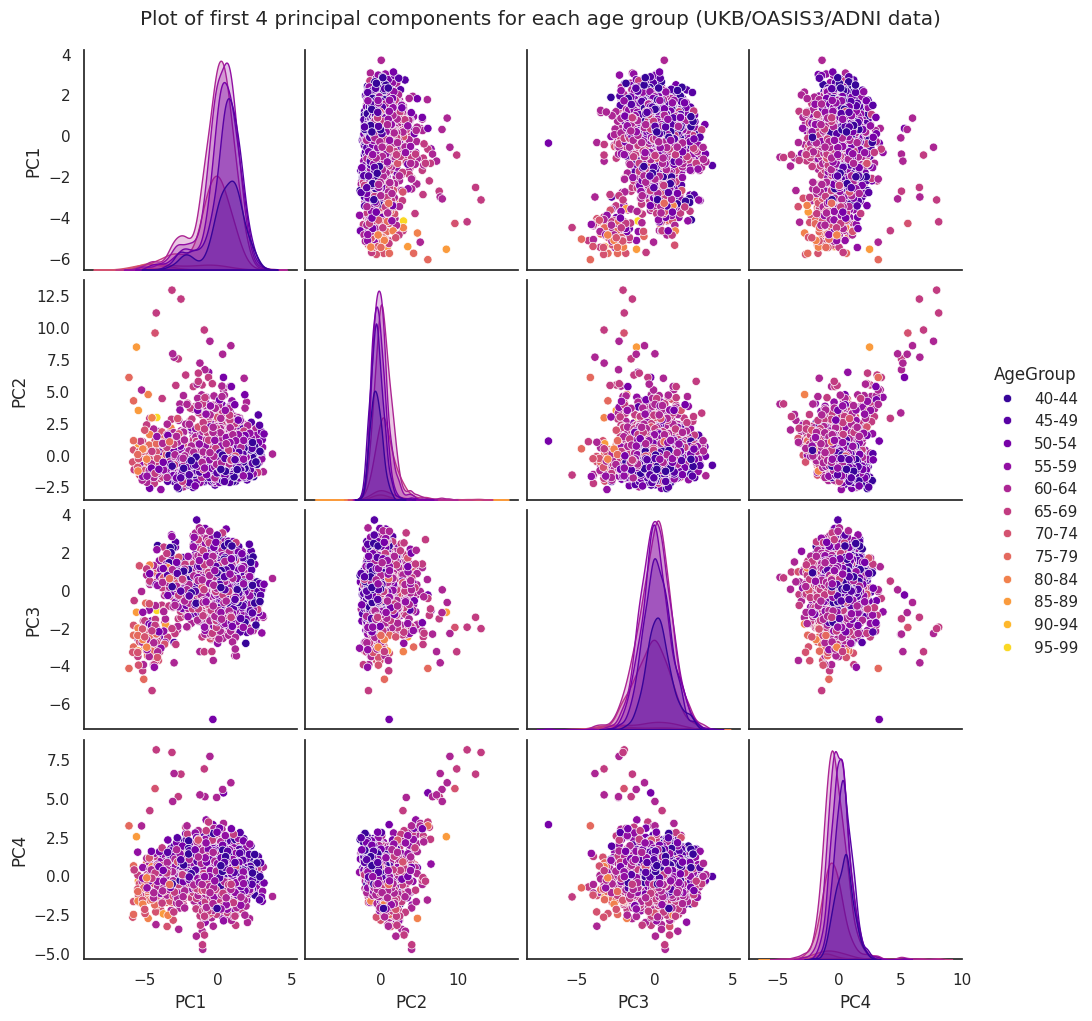

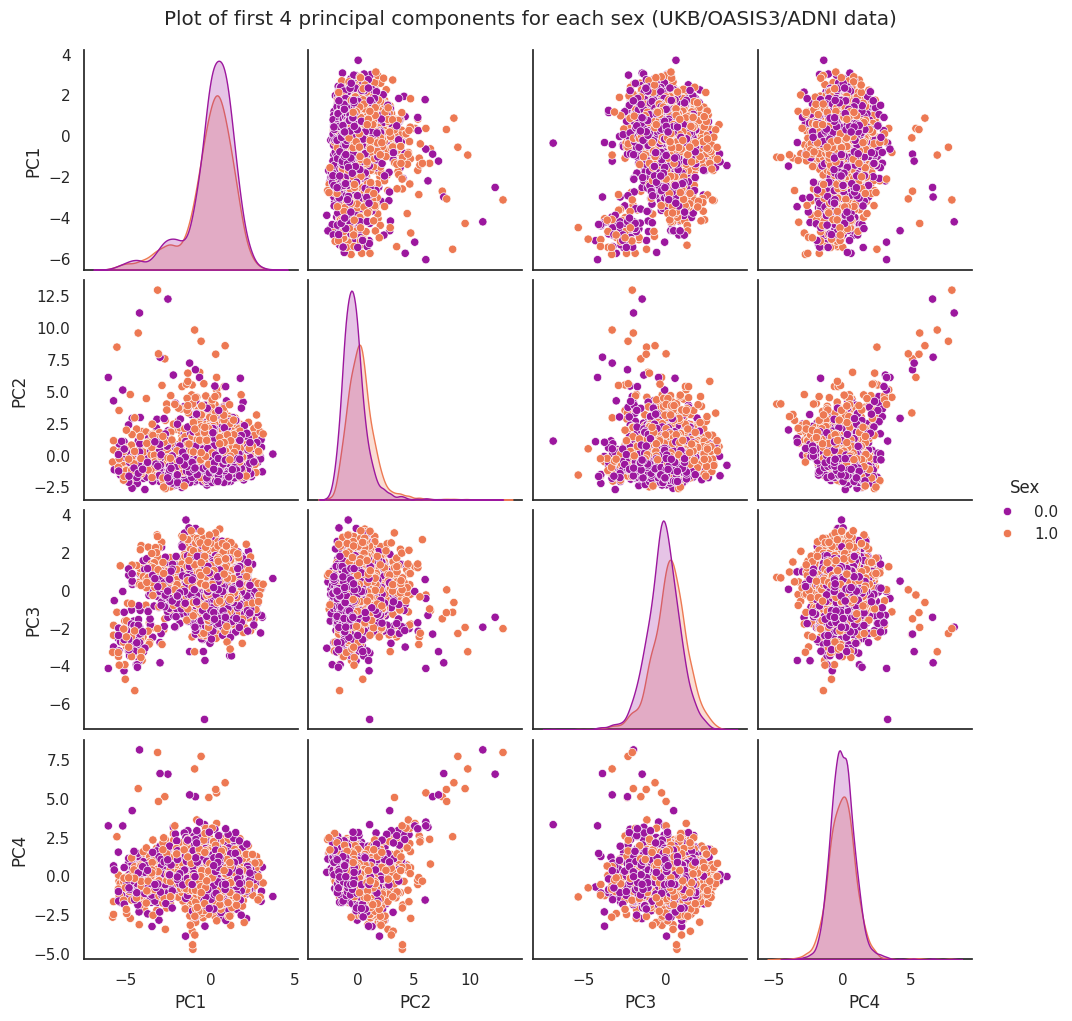

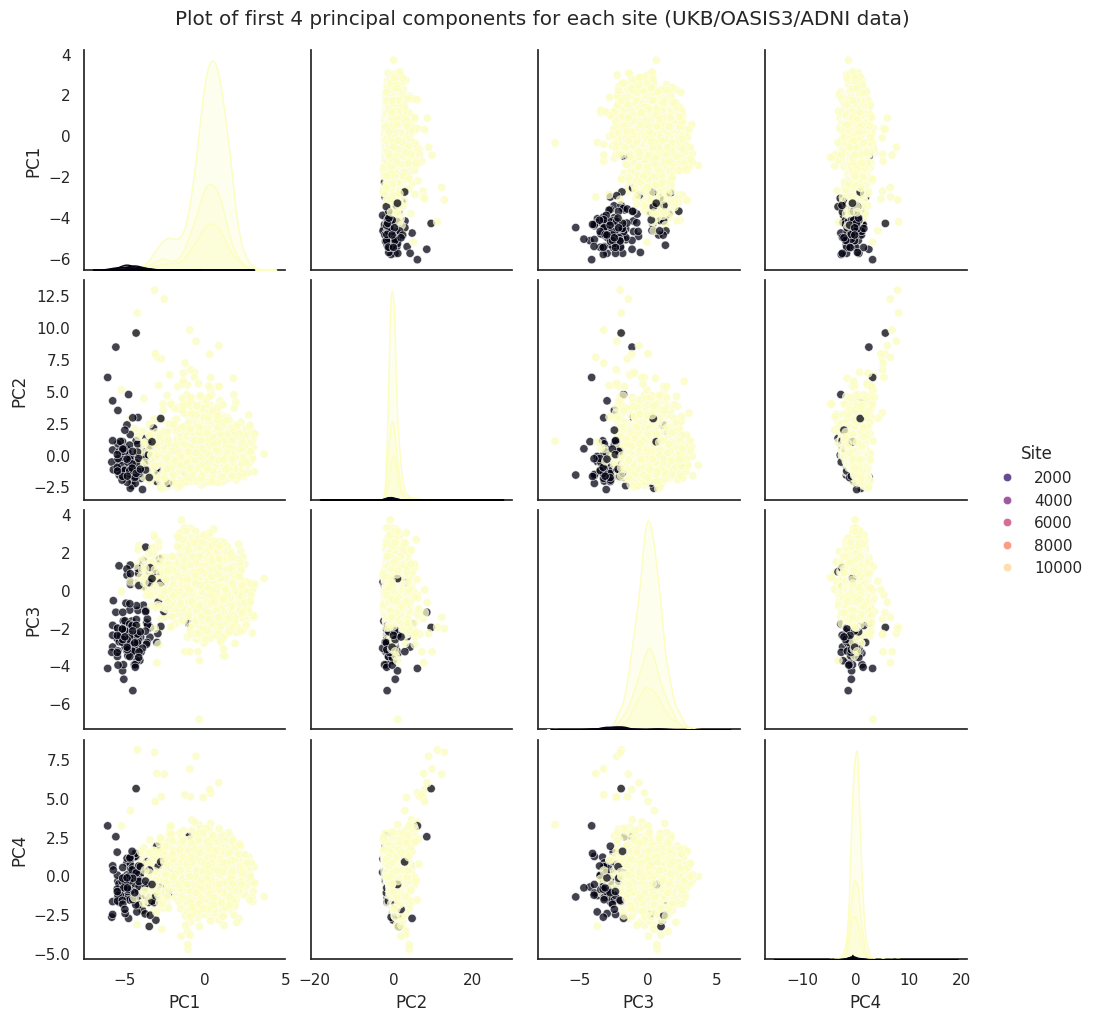

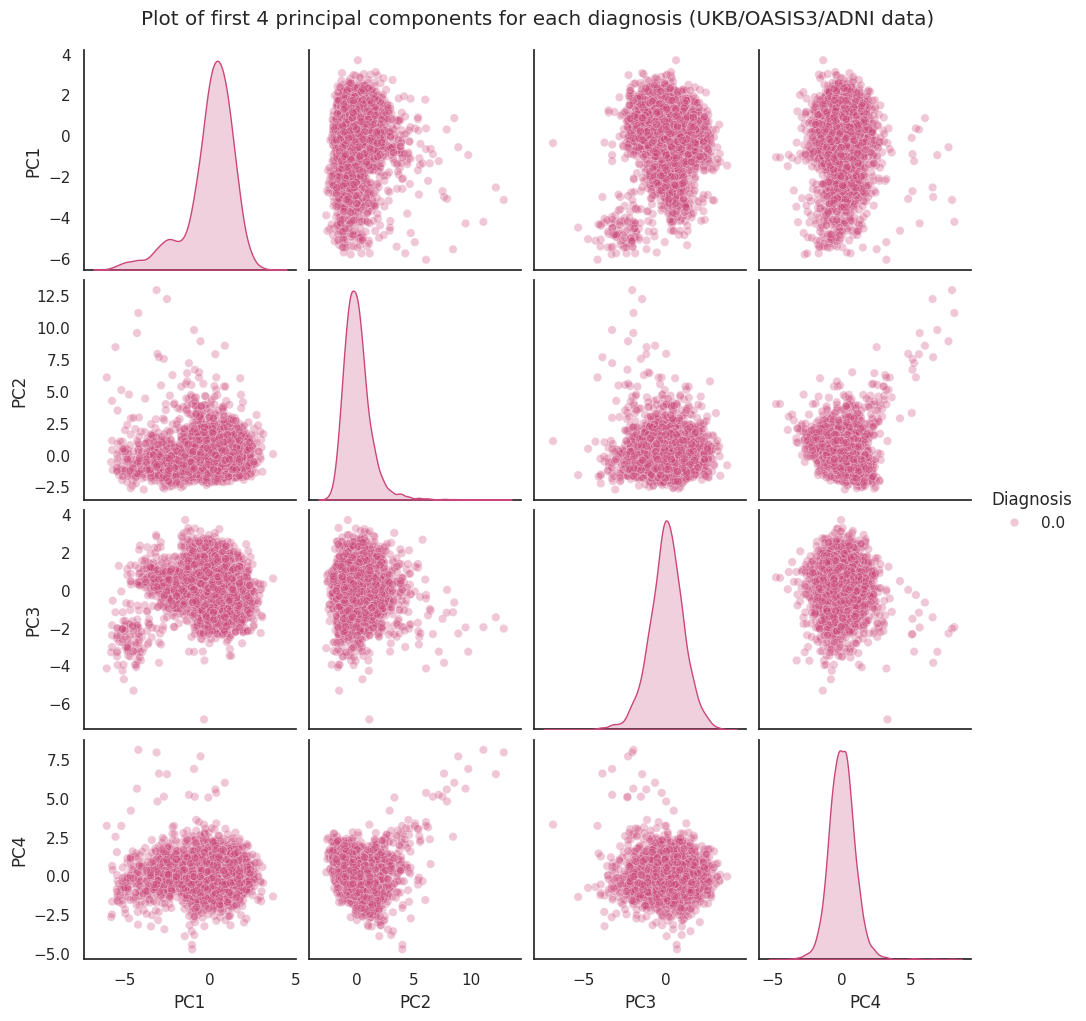

In [29]:
pca_df = pd.DataFrame(latent_pca_df_asl, columns=['PC1', 'PC2', 'PC3', 'PC4','Age','Sex','Site', 'Diagnosis'])

min_age = pca_df["Age"].min()
max_age = pca_df["Age"].max()
bins = np.arange(np.floor(min_age / 5) * 5, np.ceil(max_age / 5) * 5 + 1, 5)
pca_df['AgeGroup'] = pd.cut(
    pca_df['Age'],
    bins=bins,
    labels = [f"{int(bins[i])}-{int(bins[i+1]-1)}" for i in range(len(bins)-1)],
    right=False
)

sns.set_theme('notebook', style="white")

# plot for age
sns.pairplot(pca_df, hue="AgeGroup", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma")
plt.suptitle('Plot of first 4 principal components for each age group (UKB/OASIS3/ADNI data)', y=1.02)
plt.show()

# plot for sex
sns.pairplot(pca_df, hue="Sex", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma")
plt.suptitle('Plot of first 4 principal components for each sex (UKB/OASIS3/ADNI data)', y=1.02)
plt.show()

# plot for site
sns.pairplot(pca_df, hue="Site", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="magma", plot_kws=dict(alpha=0.75))
plt.suptitle('Plot of first 4 principal components for each site (UKB/OASIS3/ADNI data)', y=1.02)
plt.show()

# plot for diagnosis
sns.pairplot(pca_df, hue="Diagnosis", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma_r", plot_kws=dict(alpha=0.3))
plt.suptitle('Plot of first 4 principal components for each diagnosis (UKB/OASIS3/ADNI data)', y=1.02)
plt.show()


MSE: 0.1502
MAE: 0.3240
R²: 0.8498



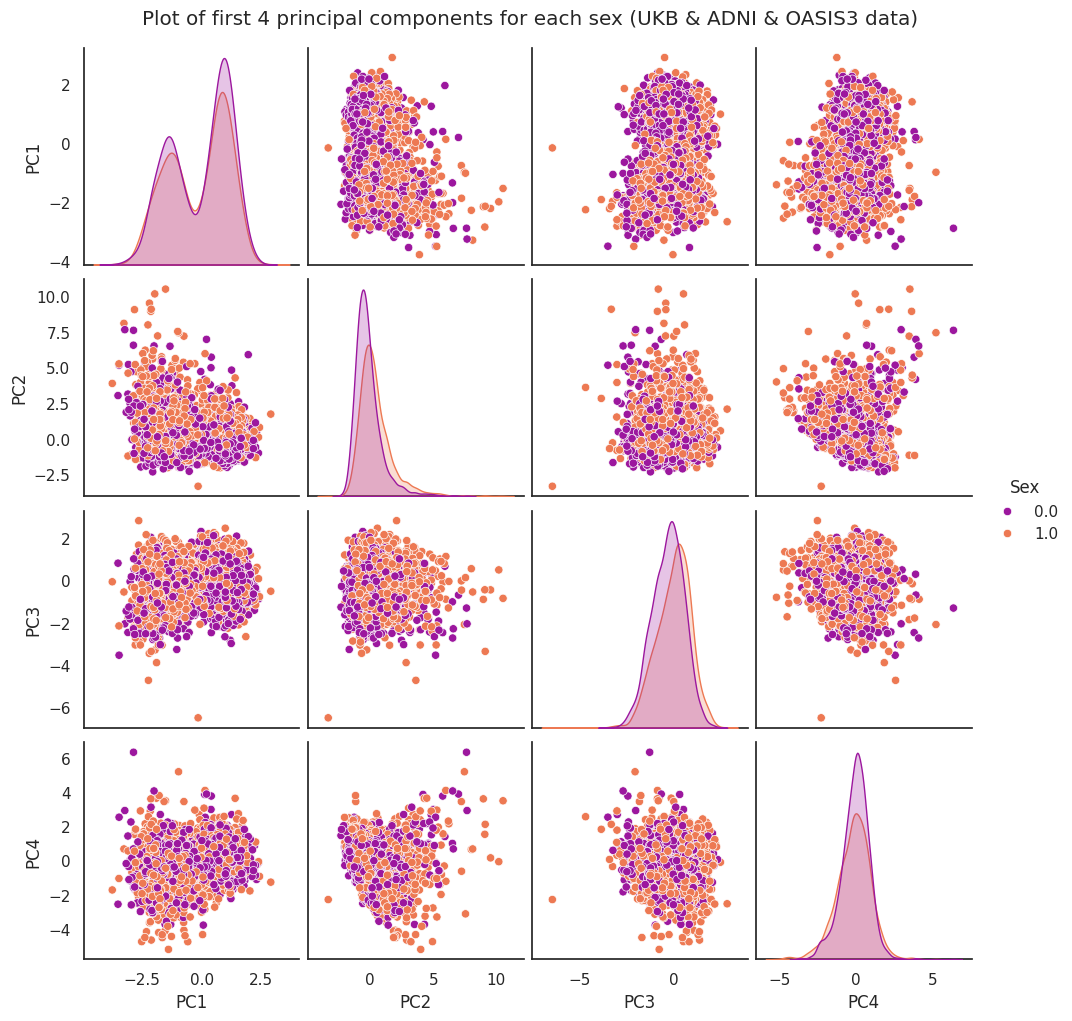

In [30]:
#now only transform the unseen data to see how well the PCA encodes for the different variables
df_pca  = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/A2_unseen_data_ukb_adni_o3.csv")
df_pca = df_pca.iloc[:,1:]
df_demo = df_pca.iloc[:,:5]
df_pca = df_pca.iloc[:,5:]
df_demo = df_demo.reset_index(drop=True)

# scale unseen data 
scaler = RobustScaler()
data_scaled = scaler.fit_transform(df_pca)
data_tensor = torch.tensor(data_scaled, dtype=torch.float32)
tensor_dataset = TensorDataset(data_tensor)

#encode data
with torch.no_grad():
    latent_representations = model.encode(data_tensor).numpy()

df_latents = pd.DataFrame(latent_representations)

#ONLY transform the unbiased data, do NOT fit!
latent_pca = pca.transform(latent_representations) 

#############
#GET SCORES#
#############
x = latent_representations
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
#get scores
x_recon = pca.inverse_transform(latent_pca)
mse = mean_squared_error(x_scaled, x_recon)
mae = mean_absolute_error(x_scaled, x_recon)
r2 = r2_score(x_scaled, x_recon)
print(f"MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}\n")



#make dataframes and concat
latent_pca_df = pd.DataFrame(latent_pca).reset_index(drop=True)
latent_pca_df
latent_pca_df_asl = latent_pca_df.join(df_demo)
latent_pca_df_asl = latent_pca_df_asl.rename(columns={i: f"PC{1+i}" for i in range(latent_pca.shape[1])})
latent_pca_df_asl["Diagnosis"] = df_demo["Diagnosis"]

pca_df = pd.DataFrame(latent_pca_df_asl, columns=['PC1', 'PC2', 'PC3', 'PC4','Age','Sex','Site', 'Diagnosis', 'Dataset'])

min_age = pca_df["Age"].min()
max_age = pca_df["Age"].max()
bins = np.arange(np.floor(min_age / 5) * 5, np.ceil(max_age / 5) * 5 + 1, 5)
pca_df['AgeGroup'] = pd.cut(
    pca_df['Age'],
    bins=bins,
    labels = [f"{int(bins[i])}-{int(bins[i+1]-1)}" for i in range(len(bins)-1)],
    right=False)

# # plot for age
# #[different color maps may be more clear with multiple plots?]
# sns.pairplot(pca_df, hue="AgeGroup", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma") 
# plt.suptitle('Plot of first 4 principal components for each age group (UKB & ADNI & OASIS3 data)', y=1.02)
# plt.show()

# plot for sex
sns.pairplot(pca_df, hue="Sex", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma")
plt.suptitle('Plot of first 4 principal components for each sex (UKB & ADNI & OASIS3 data)', y=1.02)
plt.show()

# # plot for site
# sns.pairplot(pca_df, hue="Site", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="viridis")
# plt.suptitle('Plot of first 4 principal components for each site (UKB & ADNI & OASIS3 data)', y=1.02)
# plt.show()

# # plot for diagnosis
# sns.pairplot(pca_df, hue="Diagnosis", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma_r", plot_kws=dict(alpha=0.3))
# plt.suptitle('Plot of first 4 principal components for each diagnosis (UKB & ADNI & OASIS3 data)', y=1.02)
# plt.show()

# # plot for dataset
# sns.pairplot(pca_df, hue="Dataset", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma")
# plt.suptitle('Plot of first 4 principal components for each dataset (UKB & ADNI & OASIS3 data)', y=1.02)
# plt.show()


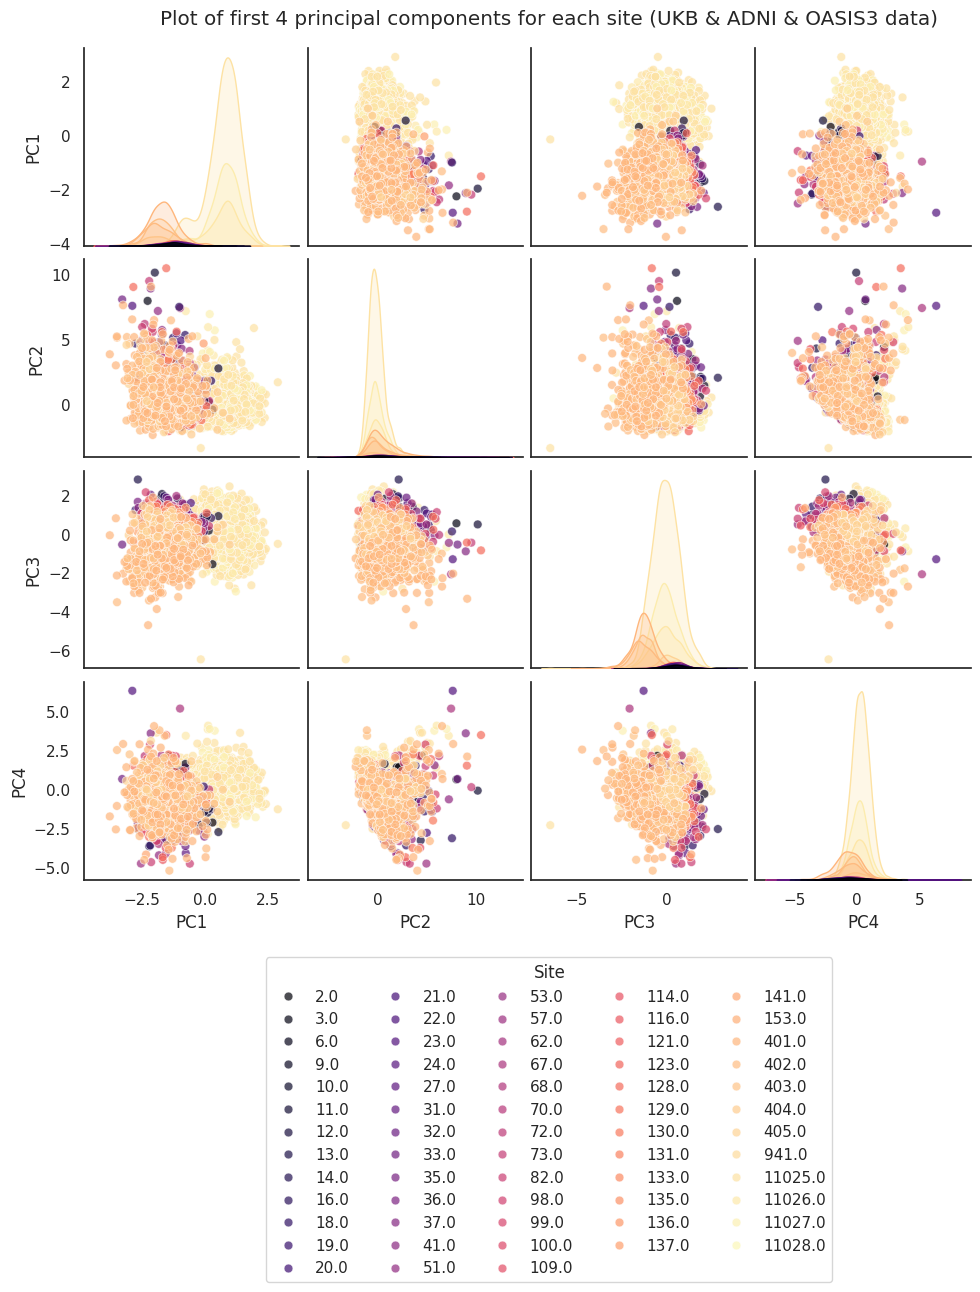

In [35]:

# import seaborn as sns
# import matplotlib.pyplot as plt

# # Number of unique sites
n_sites = pca_df["Site"].nunique()

# Create a distinct color palette
palette = sns.color_palette("magma", n_sites)

# Pairplot
g = sns.pairplot(
    pca_df,
    hue="Site",
    vars=['PC1', 'PC2', 'PC3', 'PC4'],
    palette=palette,
    plot_kws={"alpha": 0.7, "s": 40}
)


if g._legend is not None:
    sns.move_legend(
        g,
        "lower center",
        bbox_to_anchor=(0.5, -0.26),
        ncol=5,
        frameon=True
    )

plt.suptitle(
    'Plot of first 4 principal components for each site (UKB & ADNI & OASIS3 data)',
    y=1.02
)
plt.subplots_adjust(bottom=0.15)

plt.show()

# plot for site
# sns.pairplot(pca_df, hue="Site", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="spring")
# plt.suptitle('Plot of first 4 principal components for each site (UKB & ADNI & OASIS3 data)', y=1.02)
# plt.show()

# # # plot for diagnosis
# sns.pairplot(pca_df, hue="Diagnosis", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma_r", plot_kws=dict(alpha=0.3))
# plt.suptitle('Plot of first 4 principal components for each diagnosis (UKB & ADNI & OASIS3 data)', y=1.02)
# plt.show()

# # plot for dataset
# sns.pairplot(pca_df, hue="Dataset", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="magma")
# plt.suptitle('Plot of first 4 principal components for each dataset (UKB & ADNI & OASIS3 data)', y=1.02)
# plt.show()


PC1:    Cummulative variance:  22.90%,  Individual variance:  22.90%
PC2:    Cummulative variance:  40.58%,  Individual variance:  17.68%
PC3:    Cummulative variance:  52.86%,  Individual variance:  12.29%
PC4:    Cummulative variance:  63.58%,  Individual variance:  10.71%
PC5:    Cummulative variance:  73.72%,  Individual variance:  10.14%
PC6:    Cummulative variance:  82.89%,  Individual variance:  9.17%
PC7:    Cummulative variance:  89.00%,  Individual variance:  6.11%
PC8:    Cummulative variance:  93.80%,  Individual variance:  4.80%
PC9:    Cummulative variance:  97.25%,  Individual variance:  3.46%
PC10:   Cummulative variance:  100.00%,  Individual variance:  2.75%


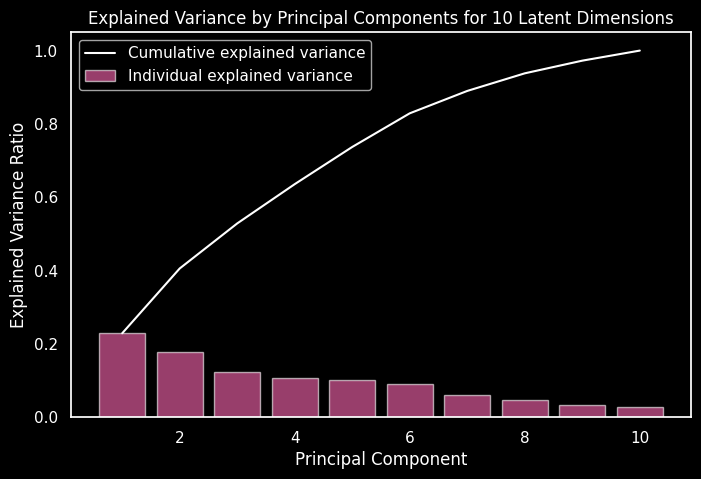

In [13]:
cummulative_variance = 0
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    cummulative_variance += var
    if i < 10: 
        print(f'PC{i}:    Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')
    else:
        print(f'PC{i}:   Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')

#plot
plt.style.use("dark_background")
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, color="hotpink" ,alpha=0.6, label='Individual explained variance')
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), color="white", label='Cumulative explained variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components for 10 Latent Dimensions')
plt.legend()
plt.grid(False)
plt.show()